# 01 — 数据清洗与特征工程

---

## 业务背景

在开始任何分析之前，我们需要先回答一个问题：**这份数据能真实反映业务状况吗？**

数据清洗不是机械地删缺失值、填异常值。每一步清理背后都应该有一个业务判断：

- 这个"异常值"是录入错误，还是真实的大客户订单？
- 这个"缺失值"是系统 bug，还是业务流程中天然就不产生这条记录？
- 退款订单该不该算进 GMV？

本 Notebook 完成以下工作：
1. 加载 5 张源表，检查数据质量
2. 日期格式转换与时间特征提取
3. 异常值检测与业务判断
4. 构建分析就绪的宽表


## 1. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 绘图风格
sns.set_style("whitegrid")                          #白色网格背景
plt.rcParams['figure.dpi'] = 100                    #图表分辨率
plt.rcParams['font.size'] = 11                      #字体大小
plt.rcParams['figure.figsize'] = (12, 5)            #默认图片尺寸为12x5
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 显示设置
pd.set_option('display.max_columns', 50)            #最多显示50列
pd.set_option('display.float_format', '{:.2f}'.format) 

C:\Users\Acer\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. 加载数据

一次性加载 5 张源表，初步观察规模和字段。

In [2]:
# 加载全部 5 张表
customers = pd.read_csv('../data/customers.csv')
products = pd.read_csv('../data/products.csv')
transactions = pd.read_csv('../data/transactions.csv')
sessions = pd.read_csv('../data/sessions.csv')
reviews = pd.read_csv('../data/reviews.csv')

# 数据规模一览
tables = {
    'customers': customers,
    'products': products,
    'transactions': transactions,
    'sessions': sessions,
    'reviews': reviews
}

print(f"{'='*60}")
print(f"{'表名':<20} {'行数':>8} {'列数':>6}")
print(f"{'='*60}")
for name, df in tables.items():
    print(f"{name:<20} {len(df):>8,} {df.shape[1]:>6}")
print(f"{'='*60}")
print(f"\n数据时间范围: 2023-01 ~ 2025-12 (3年)")

表名                         行数     列数
customers              10,000     10
products                1,000     11
transactions          120,000     11
sessions               80,000     10
reviews                25,000      8

数据时间范围: 2023-01 ~ 2025-12 (3年)


## 3. 数据质量审计

逐表检查：数据类型是否正确、是否存在缺失值、是否存在重复记录。

### 3.1 customers 表 —— 用户画像

In [135]:
print("=== 数据类型 ===")
print(customers.dtypes)
print(f"\n=== 缺失值 ===")
missing_counts = customers.isnull().sum()     #计算每一列空值总数
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "无缺失值 ✓")
print(f"\n=== 重复 customer_id ===")
dup = customers['customer_id'].duplicated().sum()
print(f"重复 ID 数: {dup}" if dup > 0 else "无重复 ✓")

=== 数据类型 ===
customer_id                  str
signup_date       datetime64[us]
age                        int64
gender                       str
country                      str
segment                      str
is_churned                 int64
lifetime_value           float64
email_opt_in               int64
has_app                    int64
dtype: object

=== 缺失值 ===
无缺失值 ✓

=== 重复 customer_id ===
无重复 ✓


In [136]:
print(f"\n=== 基础统计 ===")
print(customers.describe())


=== 基础统计 ===
                      signup_date      age  is_churned  lifetime_value  \
count                       10000 10000.00    10000.00        10000.00   
mean   2022-07-15 12:41:45.600000    35.33        0.17         1544.61   
min           2020-01-01 00:00:00    18.00        0.00           71.21   
25%           2021-08-20 00:00:00    27.00        0.00          587.94   
50%           2022-07-14 00:00:00    35.00        0.00         1043.80   
75%           2023-06-12 06:00:00    43.00        0.00         1952.15   
max           2024-12-30 00:00:00    75.00        1.00         9353.25   
std                           NaN    11.17        0.38         1426.69   

       email_opt_in  has_app  
count      10000.00 10000.00  
mean           0.70     0.56  
min            0.00     0.00  
25%            0.00     0.00  
50%            1.00     1.00  
75%            1.00     1.00  
max            1.00     1.00  
std            0.46     0.50  


**业务观察：**
- `is_churned` 是二值变量，可以分析流失用户的特征
- `segment` 已经做了预分层（Premium / Regular / Budget Shopper），后续可以和 RFM 分群做对比
- `lifetime_value` 分布范围很大（标准差接近均值），说明用户价值差异显著，这是做分层的业务前提


### 3.2 products 表 —— 商品维度

In [137]:
print("=== 数据类型 ===")
print(products.dtypes)
print(f"\n=== 缺失值 ===")
print(products.isnull().sum()[products.isnull().sum() > 0] if products.isnull().sum().sum() > 0 else "无缺失值 ✓")

=== 数据类型 ===
product_id            str
product_name          str
category              str
brand                 str
price             float64
avg_rating        float64
num_ratings         int64
stock_quantity      int64
discount_pct        int64
is_featured         int64
weight_kg         float64
dtype: object

=== 缺失值 ===
无缺失值 ✓


In [138]:
print(f"\n=== 品类分布 ===")
print(products['category'].value_counts())
print(f"\n=== 价格分布 ===")
print(products['price'].describe())


=== 品类分布 ===
category
Health             91
Sports             75
Food & Grocery     75
Office Supplies    73
Electronics        73
Jewelry            72
Clothing           71
Automotive         69
Pet Supplies       68
Home & Garden      67
Toys               60
Software           54
Music              52
Beauty             50
Books              50
Name: count, dtype: int64

=== 价格分布 ===
count   1000.00
mean      57.61
std       64.20
min        3.71
25%       19.77
50%       36.09
75%       68.92
max      520.45
Name: price, dtype: float64


**业务观察：**
- 15 个品类，其中 Sports、Books 的商品数量最多，不一定销售额就高
- 有`discount_pct`完整数据，可以分析折扣对转化的真实效果
- `avg_rating` 已有预计算评分，可以验证和 reviews 表的一致性


### 3.3 transactions 表 —— 交易记录（核心事实表）

In [241]:
print("=== 数据类型 ===")
print(transactions.dtypes)
print(f"\n=== 缺失值 ===")
print(transactions.isnull().sum()[transactions.isnull().sum() > 0] if transactions.isnull().sum().sum() > 0 else "无缺失值 ✓")

=== 数据类型 ===
transaction_id                 str
customer_id                    str
product_id                     str
transaction_date    datetime64[us]
quantity                     int64
unit_price                 float64
total_amount               float64
discount_applied             int64
status                         str
payment_method                 str
shipping_cost              float64
year                         int32
month                        int32
year_month               period[M]
day_of_week                  int32
day_of_week_name               str
hour                         int32
quarter                      int32
is_weekend                   int64
dtype: object

=== 缺失值 ===
无缺失值 ✓


In [242]:
print(f"\n=== 订单状态分布 ===")
print(transactions['status'].value_counts())
print(f"\n=== 支付方式分布 ===")
print(transactions['payment_method'].value_counts())
print(f"\n=== 基础统计 ===")
print(transactions[['quantity', 'unit_price', 'total_amount', 'discount_applied', 'shipping_cost']].describe())


=== 订单状态分布 ===
status
completed    68700
refunded     17139
cancelled    17092
pending      17069
Name: count, dtype: int64

=== 支付方式分布 ===
payment_method
credit_card      41769
debit_card       24163
paypal           21721
apple_pay        14350
google_pay       11977
bank_transfer     6020
Name: count, dtype: int64

=== 基础统计 ===
       quantity  unit_price  total_amount  discount_applied  shipping_cost
count 120000.00   120000.00     120000.00         120000.00      120000.00
mean       1.47       53.50         78.45              7.11           4.06
std        1.14       61.17        128.62             13.76           3.70
min        1.00        2.68          2.68              0.00           0.00
25%        1.00       18.52         21.46              0.00           0.00
50%        1.00       33.23         40.58              0.00           4.83
75%        1.00       64.44         85.12              5.00           7.41
max       19.00      520.45       6540.69             50.00       

**业务观察：**
- 订单状态有三种：`completed`（正常完成）、`cancelled`（取消）、`refunded`（退款）
- 计算 GMV 时仅保留 `completed` 状态，`cancelled` 和 `refunded` 用来分析退货率
- 单笔交易金额`unit_price`跨度很大，需要检查是否合理


### 3.4 sessions 表 —— 用户行为日志

In [243]:
print("=== 数据类型 ===")
print(sessions.dtypes)
print(f"\n=== 缺失值 ===")
print(sessions.isnull().sum()[sessions.isnull().sum() > 0] if sessions.isnull().sum().sum() > 0 else "无缺失值 ✓")
print(f"\n=== 设备分布 ===")
print(sessions['device'].value_counts())

=== 数据类型 ===
session_id                     str
customer_id                    str
session_date        datetime64[us]
device                         str
channel                        str
duration_seconds             int64
pages_viewed                 int64
converted                    int64
bounced                      int64
cart_additions               int64
year                         int32
month                        int32
year_month               period[M]
day_of_week                  int32
hour                         int32
is_weekend                   int64
dtype: object

=== 缺失值 ===
无缺失值 ✓

=== 设备分布 ===
device
mobile     40010
desktop    28053
tablet     11937
Name: count, dtype: int64


In [244]:
print(f"\n=== 渠道分布 ===")
print(sessions['channel'].value_counts())
print(f"\n=== 转化标志 ===")
print(sessions['converted'].value_counts())
print(f"\n转化率: {sessions['converted'].mean():.2%}")


=== 渠道分布 ===
channel
organic        19974
paid_search    15915
social         12071
direct         12067
email          11854
referral        8119
Name: count, dtype: int64

=== 转化标志 ===
converted
0    71352
1     8648
Name: count, dtype: int64

转化率: 10.81%


**业务观察：**
- `converted` 标记了该次查看是否最终产生了购买
- `bounced` 标记了该次查看是否只看了一页就走了
- `cart_additions` 记录了加购次数 —— 这 3 个字段是漏斗分析的核心


### 3.5 reviews 表 —— 用户评价

In [245]:
print("=== 数据类型 ===")
print(reviews.dtypes)
print(f"\n=== 缺失值 ===")
print(reviews.isnull().sum()[reviews.isnull().sum() > 0] if reviews.isnull().sum().sum() > 0 else "无缺失值 ✓")
print(f"\n=== 评分分布 ===")
print(reviews['rating'].value_counts().sort_index())
print(f"\n=== 是否有已验证购买标记 ===")
print(reviews['verified_purchase'].value_counts())

=== 数据类型 ===
review_id                       str
customer_id                     str
product_id                      str
review_date          datetime64[us]
rating                        int64
review_text                     str
helpful_votes                 int64
verified_purchase             int64
dtype: object

=== 缺失值 ===
无缺失值 ✓

=== 评分分布 ===
rating
1    1361
2    4183
3    8031
4    7616
5    3809
Name: count, dtype: int64

=== 是否有已验证购买标记 ===
verified_purchase
1    19982
0     5018
Name: count, dtype: int64


**业务观察：**
- 有 `verified_purchase` 字段，可以区分那些是真实的购买评价
- `helpful_votes` 可以分析哪些评价被其他用户认可，用于商品详情页排序
- `review_text` 可用于文本情感分析，验证评分和文本是否一致


## 4. 表关联关系验证

在正式合并之前，先验证外键的完整性：transactions 中的 customer_id 和 product_id 是否都能在对应的维度表中找到？

In [246]:
# 检查 transactions 中的 customer_id 是否都在 customers 表中
txn_customers = set(transactions['customer_id'])
cust_ids = set(customers['customer_id'])
orphan_customers = txn_customers - cust_ids
print(f"Transactions 中 customer_id 总数: {len(txn_customers):,}")
print(f"在 customers 表中找不到的 customer_id: {len(orphan_customers)}")

# 检查 transactions 中的 product_id 是否都在 products 表中
txn_products = set(transactions['product_id'])
prod_ids = set(products['product_id'])
orphan_products = txn_products - prod_ids
print(f"\nTransactions 中 product_id 总数: {len(txn_products):,}")
print(f"在 products 表中找不到的 product_id: {len(orphan_products)}")

# 同样检查 sessions 和 reviews
sess_customers = set(sessions['customer_id'])
orphan_sess = sess_customers - cust_ids
print(f"\nSessions 中找不到的 customer_id: {len(orphan_sess)}")

rev_customers = set(reviews['customer_id'])
orphan_rev = rev_customers - cust_ids
print(f"Reviews 中找不到的 customer_id: {len(orphan_rev)}")

rev_products = set(reviews['product_id'])
orphan_rev_prod = rev_products - prod_ids
print(f"Reviews 中找不到的 product_id: {len(orphan_rev_prod)}")

Transactions 中 customer_id 总数: 9,941
在 customers 表中找不到的 customer_id: 0

Transactions 中 product_id 总数: 1,000
在 products 表中找不到的 product_id: 0

Sessions 中找不到的 customer_id: 0
Reviews 中找不到的 customer_id: 0
Reviews 中找不到的 product_id: 0


**结论：** 外键关联完整，所有交易、会话、评论中的 `customer_id` 和 `product_id` 都能在维度表中找到。可以直接进行多表连接。

## 5. 日期字段处理

所有日期字段目前是字符串格式，需要转为 datetime，并提取年月日小时等时间维度。

In [247]:
# 转换所有日期字段
date_cols = {
    'customers': ['signup_date'],
    'transactions': ['transaction_date'],
    'sessions': ['session_date'],
    'reviews': ['review_date']
}

for table_name, cols in date_cols.items():
    df = tables[table_name]
    for col in cols:
        df[col] = pd.to_datetime(df[col])

# 验证转换结果
for table_name, cols in date_cols.items():
    df = tables[table_name]
    for col in cols:
        print(f"{table_name}.{col}: {df[col].dtype}, 范围 {df[col].min()} ~ {df[col].max()}")

customers.signup_date: datetime64[us], 范围 2020-01-01 00:00:00 ~ 2024-12-30 00:00:00
transactions.transaction_date: datetime64[us], 范围 2023-01-01 00:23:39 ~ 2024-12-30 23:59:05
sessions.session_date: datetime64[us], 范围 2023-01-01 00:24:50 ~ 2024-12-30 23:43:52
reviews.review_date: datetime64[us], 范围 2023-01-01 00:00:00 ~ 2024-12-30 00:00:00


**业务观察：**
- 大部分数据覆盖 2023-01-01 到 2024-12-30，恰好2年
- `signup_date` 最早可以追溯到 2020 年，说明有3年老用户，可能能做同期群分析


## 6. 提取时间特征

从日期中提取可用于后续分析的时间维度。

In [248]:
# 为 transactions 提取时间维度（后续分析最常用的表）
transactions['year'] = transactions['transaction_date'].dt.year
transactions['month'] = transactions['transaction_date'].dt.month
#year_month--月度趋势、同比环比
transactions['year_month'] = transactions['transaction_date'].dt.to_period('M')
#day_of_week--周末 vs 工作日	
transactions['day_of_week'] = transactions['transaction_date'].dt.dayofweek
transactions['day_of_week_name'] = transactions['transaction_date'].dt.day_name()
#hour--用户活跃时段，推流时机分析
transactions['hour'] = transactions['transaction_date'].dt.hour
#quarter--季度分析
transactions['quarter'] = transactions['transaction_date'].dt.quarter
transactions['is_weekend'] = transactions['day_of_week'].isin([5, 6]).astype(int)

# 同样处理 sessions
sessions['year'] = sessions['session_date'].dt.year
sessions['month'] = sessions['session_date'].dt.month
sessions['year_month'] = sessions['session_date'].dt.to_period('M')
sessions['day_of_week'] = sessions['session_date'].dt.dayofweek
sessions['hour'] = sessions['session_date'].dt.hour
sessions['is_weekend'] = sessions['day_of_week'].isin([5, 6]).astype(int)

## 7. 异常值检测与业务判断

这是数据清洗中最需要**业务判断**的环节。不是所有统计上的"异常值"都该删。

### 7.1 交易金额异常值检查

用 IQR 方法识别极端值，然后逐条判断：是数据错误还是真实的大单？

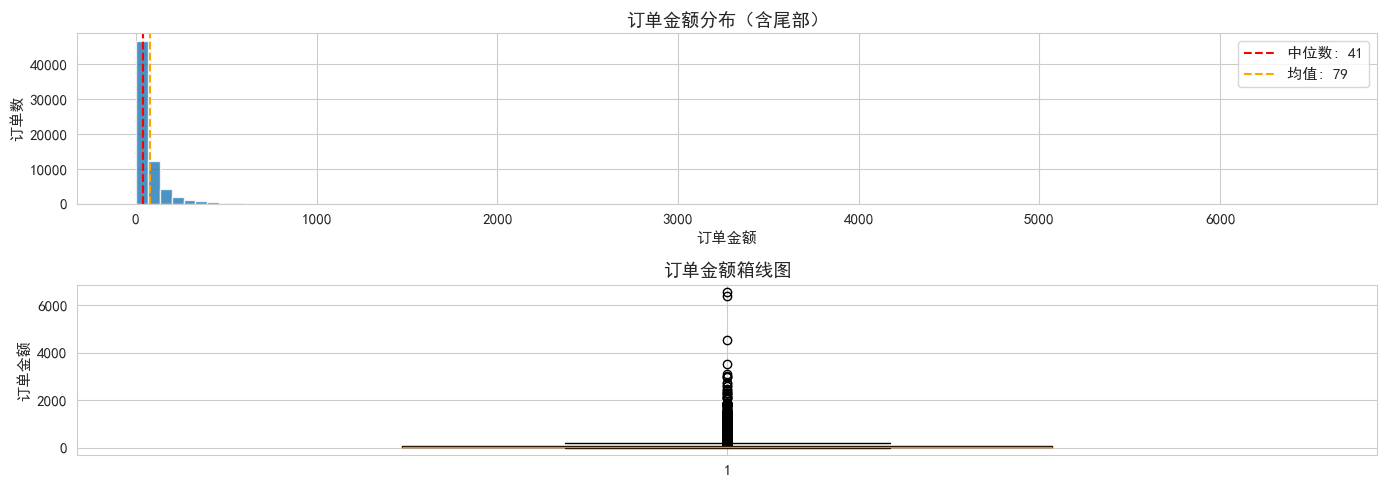

Q1: 21.47, Q3: 85.97, IQR: 64.50
上界 (3×IQR): 279.47
超过上界的订单数: 3128 / 68700 (4.55%)

极端大单样本 (top 10):
       transaction_id customer_id  total_amount  quantity  unit_price
119813        T098387      C07554       6540.69        13      503.13
59891         T055278      C03716       6391.00        14      456.50
57553         T020073      C03610       4528.17         9      503.13
71556         T015537      C02833       3521.91         7      503.13
53080         T088315      C09168       3122.70         6      520.45
58964         T073773      C05905       3018.78         6      503.13
119436        T036012      C02598       2997.30        15      199.82
50351         T117393      C06991       2964.88         8      370.61
114245        T022026      C06839       2739.00         6      456.50
119074        T042604      C01875       2739.00         6      456.50


In [ ]:
# 只看 completed 订单的金额分布
completed = transactions[transactions['status'] == 'completed'].copy()
#搭建画板，两行一列
fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# 直方图
axes[0].hist(completed['total_amount'], bins=100, edgecolor='white', alpha=0.8)
axes[0].axvline(completed['total_amount'].median(), color='red', linestyle='--', label=f"中位数: {completed['total_amount'].median():.0f}")
axes[0].axvline(completed['total_amount'].mean(), color='orange', linestyle='--', label=f"均值: {completed['total_amount'].mean():.0f}")
axes[0].set_title('订单金额分布（含尾部）')
axes[0].set_xlabel('订单金额')
axes[0].set_ylabel('订单数')
axes[0].legend()

# 箱线图
axes[1].boxplot(completed['total_amount'].values, vert=True, widths=0.5)
axes[1].set_title('订单金额箱线图')
axes[1].set_ylabel('订单金额')

plt.tight_layout()
plt.show()

# IQR (四分位距)异常值检测
Q1 = completed['total_amount'].quantile(0.25)
Q3 = completed['total_amount'].quantile(0.75)
IQR = Q3 - Q1
#上限红线
upper_bound = Q3 + 3 * IQR  # 用 3 倍 IQR 而非 1.5，数据中有大单，减少误杀
outliers = completed[completed['total_amount'] > upper_bound]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"上界 (3×IQR): {upper_bound:.2f}")
print(f"超过上界的订单数: {len(outliers)} / {len(completed)} ({len(outliers)/len(completed):.2%})")
print(f"\n极端大单样本 (top 10):")
#通过排序函数选择最大的十个值,并显示[]内的数据
print(outliers.nlargest(10, 'total_amount')[['transaction_id', 'customer_id', 'total_amount', 'quantity', 'unit_price']])

### 7.2 业务判断：这些大单该删吗？

对于排在前十的超级大单，我们需要逐一判断：

- **quantity 正常 + unit_price 高** → 这是买了高单价商品，属于正常业务行为，**保留**
- **quantity 极高** → 可能是批发采购或 B 端客户，**保留但标记**
- **total_amount = unit_price × quantity 明显不匹配** → 可能是数据错误，**修复或删除**

In [275]:
expected_amount = transactions['quantity'] * transactions['unit_price']
diff = (expected_amount - transactions['total_amount']).abs()
#制表误差
small_mistakes = transactions[(diff > 0) & (diff <= 0.1)]
#严重错误
big_errors = transactions[diff > 0.1]

print(f"微小误差订单数 (误差 <= 0.1): {len(small_mistakes )}")
if len(small_mistakes ) > 0:
    print(small_mistakes [['transaction_id', 'quantity', 'unit_price', 'total_amount']].head())

print(f"\n严重错误订单数 (误差 > 0.1): {len(big_errors)}")
if len(big_errors) > 0:
    print(big_errors[['transaction_id', 'quantity', 'unit_price', 'total_amount']].head())

微小误差订单数 (误差 <= 0.1): 6791
    transaction_id  quantity  unit_price  total_amount
51         T067772         2       59.61        119.21
56         T038962         3       32.87         98.61
122        T042537         3       67.14        201.42
133        T115303         2       67.98        135.97
147        T036698         3       45.13        135.38

严重错误订单数 (误差 > 0.1): 0


**我们的决策：** 没有明显的不匹配，不做硬删除。在后续分析中按场景决定是否过滤。例如计算客单价时排除极端值，但计算 GMV 时全部保留。

### 7.3 退货与取消订单分析

`cancelled` 和 `refunded` 订单占多少？是否有时间规律？

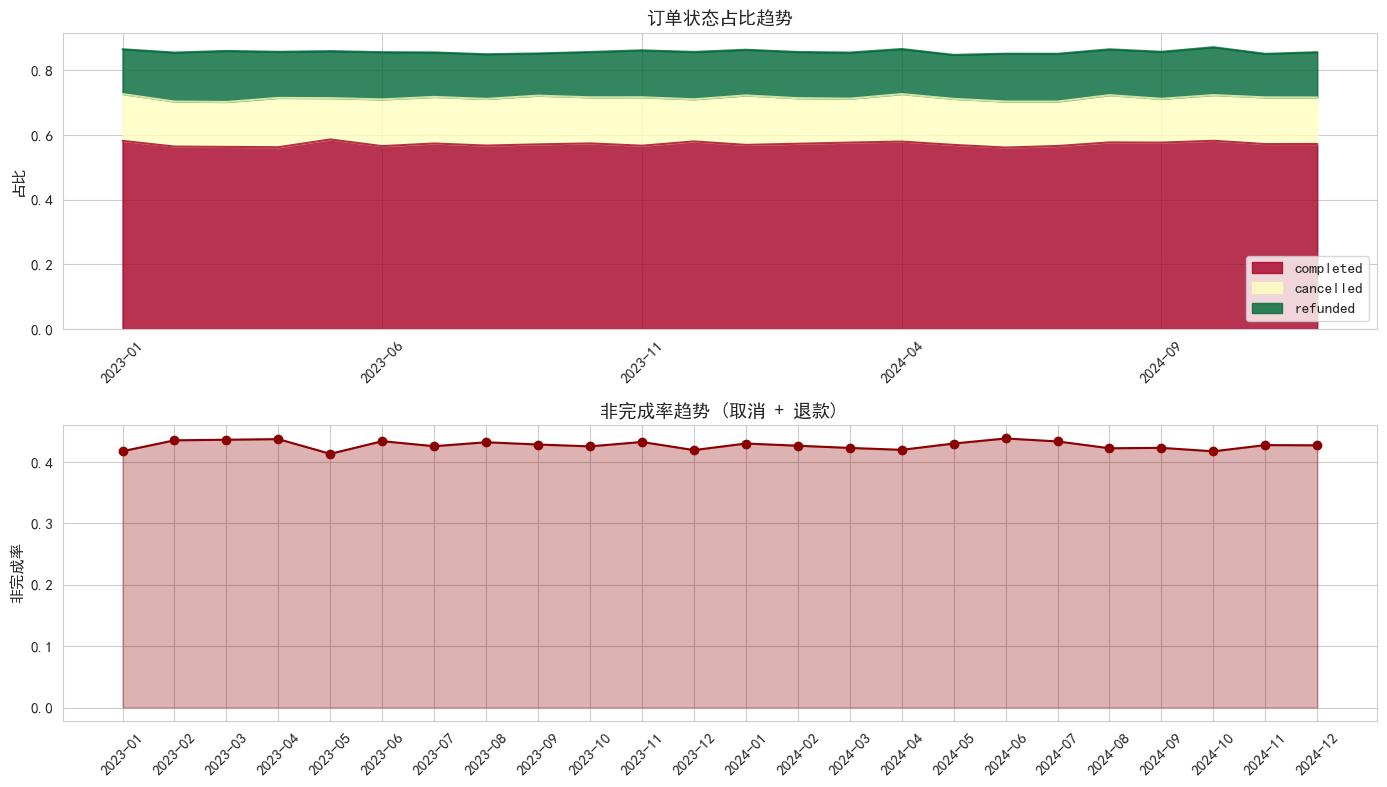

In [284]:
# 订单状态按月趋势
status_monthly = transactions.groupby(['year_month', 'status']).size().unstack(fill_value=0)
status_monthly.index = status_monthly.index.astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 堆叠面积图 —— 各状态占比
status_pct = status_monthly.div(status_monthly.sum(axis=1), axis=0)
status_pct[['completed', 'cancelled', 'refunded']].plot.area(
    ax=axes[0], stacked=True, alpha=0.8, colormap='RdYlGn'
)
axes[0].set_title('订单状态占比趋势')
axes[0].set_ylabel('占比')
axes[0].set_xlabel('')
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=45)

# 退货率 + 取消率趋势
non_complete_pct = 1 - status_pct['completed']
axes[1].plot(non_complete_pct.index, non_complete_pct.values, marker='o', color='darkred')
axes[1].fill_between(range(len(non_complete_pct)), non_complete_pct.values, alpha=0.3, color='darkred')
axes[1].set_title('非完成率趋势 (取消 + 退款)')
axes[1].set_ylabel('非完成率')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**业务观察：**
- 非完成率约在数据中占一定比例，这是电商的正常水平（行业一般在 5-15%）
- 如果某个时间段非完成率突然飙升，需要排查是否与特定促销活动或商品质量问题相关
- 总体属于正常数据，没有发现反常数据

## 8. 构建分析宽表

将所有表关联成一张大宽表，方便后续直接使用。这是**一次 JOIN，处处复用**。

连接关系：
```
customers ──┐
            ├── transactions (事实表) ── products
            │
sessions ───┤
            │
reviews ────┘
```

In [277]:
# 构建交易宽表: transactions + customers + products
txn_wide = (
    transactions
    .merge(customers, on='customer_id', how='left')
    .merge(products, on='product_id', how='left')
)

# 构建会话宽表: sessions + customers
sess_wide = (
    sessions
    .merge(customers, on='customer_id', how='left')
)

# 构建评论宽表: reviews + customers + products
rev_wide = (
    reviews
    .merge(customers[['customer_id', 'segment', 'country']], on='customer_id', how='left')
    .merge(products[['product_id', 'category', 'brand', 'price']], on='product_id', how='left')
)

print(f"交易宽表: {txn_wide.shape[0]:,} rows × {txn_wide.shape[1]} cols")
print(f"会话宽表: {sess_wide.shape[0]:,} rows × {sess_wide.shape[1]} cols")
print(f"评论宽表: {rev_wide.shape[0]:,} rows × {rev_wide.shape[1]} cols")
print("\n宽表构建完成 ✓")

交易宽表: 120,000 rows × 38 cols
会话宽表: 80,000 rows × 25 cols
评论宽表: 25,000 rows × 13 cols

宽表构建完成 ✓


## 9. 数据导出

将清洗后的数据保存为 parquet 格式（比 CSV 更快，保留数据类型），供后续 Notebook 使用。

In [278]:
import os
os.makedirs('../output', exist_ok=True)

# 保存清洗后的核心表
txn_wide.to_parquet('../output/transactions_wide.parquet', index=False)
sess_wide.to_parquet('../output/sessions_wide.parquet', index=False)
rev_wide.to_parquet('../output/reviews_wide.parquet', index=False)

# 也保存单独的表（某些场景不需要 JOIN 全部字段）
customers.to_parquet('../output/customers_clean.parquet', index=False)
products.to_parquet('../output/products_clean.parquet', index=False)
sessions.to_parquet('../output/sessions_clean.parquet', index=False)
transactions.to_parquet('../output/transactions_clean.parquet', index=False)

print("数据导出完成 ✓")
print("\n输出文件:")
for f in os.listdir('../output'):
    if f.endswith('.parquet'):
        size_mb = os.path.getsize(f'../output/{f}') / 1024 / 1024
        print(f"  {f} ({size_mb:.1f} MB)")

数据导出完成 ✓

输出文件:
  customers_clean.parquet (0.2 MB)
  products_clean.parquet (0.0 MB)
  reviews_wide.parquet (0.4 MB)
  sessions_clean.parquet (1.8 MB)
  sessions_wide.parquet (2.2 MB)
  transactions_clean.parquet (3.0 MB)
  transactions_wide.parquet (4.6 MB)


---

## 10. 小结

| 步骤 | 做了什么 | 关键业务决策 |
|------|---------|-------------|
| 数据加载 | 5 张表，共计 ~23.5 万行 | 确认数据规模适合分析 |
| 质量审计 | 检查类型、缺失、重复 | 数据质量好，0 缺失值 |
| 外键验证 | 验证 customer_id / product_id 完整性 | JOIN 不会丢数据 |
| 日期处理 | 字符串 → datetime | 数据覆盖 2023-2025 |
| 特征工程 | 提取 year / month / day_of_week / hour 等 | 为后续趋势分析做准备 |
| 异常值 | IQR 检测大单，分析退货率 | 不删大单，按场景过滤 |
| 宽表构建 | 5 表 JOIN 成 3 张分析宽表 | 一次 JOIN，后续复用 |
| 数据导出 | parquet 格式 | 比 CSV 快，保留 dtype |

**关键 Takeaways：**
1. 数据质量总体良好：无缺失值，外键关联完整
2. 订单状态中 cancelled + refunded 需要单独处理，GMV 仅计算 completed
3. 用户 LTV 分布极不均匀（标准差 ≈ 均值），说明用户价值分层是合理的分析方向
4. 3 年的数据跨度 + sessions 行为日志，为漏斗分析和同期群分析提供了足够的时间深度
